In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
from joblib import Parallel, delayed
from tqdm import tqdm

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [5]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose(
        [Magnitude(), 
         LogMapping(c = 1000.0), 
         NumpyToTensor3Channel()]
    ),
    loader = mat_file_loader
)

meas_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose(
        [Magnitude(), 
         LogMapping(c = 1000.0), 
         NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
synth_paths = [s[0] for s in no_aug_synth_ds.samples]

TS_synth_cache = {}
for path in tqdm(synth_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    TS_synth_cache[path] = (T + S).astype(np.uint8)

meas_paths = [s[0] for s in meas_ds.samples]

TS_meas_cache = {}
for path in tqdm(meas_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    TS_meas_cache[path] = (T + S).astype(np.uint8)

100%|███████████████████████████████████████████████████████████████████████████████| 1345/1345 [01:10<00:00, 19.18it/s]


In [6]:
synth_paths = [s[0] for s in no_aug_synth_ds.samples]

T_synth_cache = {}
for path in tqdm(synth_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    T_synth_cache[path] = (T).astype(np.uint8)

meas_paths = [s[0] for s in meas_ds.samples]

T_meas_cache = {}
for path in tqdm(meas_paths):
    img = mat_file_loader(path)
    img = LogMapping(c=1000.0)(Magnitude()(img))
    T, S, _ = zhao_segmentation_v2(img)
    T_meas_cache[path] = (T).astype(np.uint8)

100%|███████████████████████████████████████████████████████████████████████████████| 1345/1345 [01:07<00:00, 20.05it/s]


In [7]:
# TS_synth_ds = DatasetFolderWithPath(
#     os.path.join(data_workspace, "mat_files/synth"),
#     extensions=(".mat"),
#     transform=transforms.Compose([
#         Magnitude(),
#         LogMapping(c=1000.0),
#         MaskedAugmentation(augmentation=SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), 
#                            fill=0, 
#                            mask_cache=TS_synth_cache),
#         NumpyToTensor3Channel()
#     ]),
#     loader=mat_file_loader
# )

# TS_meas_ds = DatasetFolderWithPath(
#     os.path.join(data_workspace, "mat_files/real"),
#     extensions=(".mat"),
#     transform=transforms.Compose([
#         Magnitude(),
#         LogMapping(c=1000.0),
#         MaskedAugmentation(augmentation=identity, fill=0, mask_cache=TS_meas_cache),
#         NumpyToTensor3Channel()
#     ]),
#     loader=mat_file_loader
# )

T_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), 
                           fill=0, 
                           mask_cache=T_synth_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

T_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=T_meas_cache),
        NumpyToTensor3Channel()
    ]),
    loader=mat_file_loader
)

In [8]:
train_ds = T_synth_ds
test_ds = T_meas_ds

ds_dict = {"train" : train_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "test": len(test_ds)}

In [11]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

train_loss = []
# val_loss = []
train_acc =[]
# val_acc = []

for i, seed in enumerate(seed_lst):
    start = time.perf_counter()
    print(f"Training Run {i}: seed {seed}")

    set_seed(seed)

    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        # "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    # load pre-trained model
    model = models.resnet18(weights = None)

    # Replace final layer for the number of classes
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 2e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
    # scheduler = OneCycleLR(
    #     optimizer, 
    #     max_lr = 2.5e-4, 
    #     steps_per_epoch = len(dataloaders["train"]), 
    #     epochs = 100
    #     )
        
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        # "val_loss" : [],
        "train_acc": [],
        # "val_acc" : []
    }
    
    # Training loops
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
        for phase in ["train"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        # scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
    
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
    
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
        
    print("Training complete!")
    
    train_loss.append(history["train_loss"])
    # val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    # val_acc.append(history["val_acc"])
    
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/SSR_w_noise/target_only/rn18_seed{seed}_b16.pth"))

    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")
    
train_loss = np.array(train_loss)
# val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
# val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 0.7142707468 Acc: 0.7613382900
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 0.1270013856 Acc: 0.9650557621
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.1347008088 Acc: 0.9553903346
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.0723272929 Acc: 0.9851301115
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.0365449688 Acc: 0.9910780669
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.0474441065 Acc: 0.9851301115
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.0856311830 Acc: 0.9732342007
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.0640005742 Acc: 0.9814126394
Epoch 7 LR: 0.0002988184
Epoch 8
train Loss: 0.0335281551 Acc: 0.9903345725
Epoch 8 LR: 0.0002985050
Epoch 9
train Loss: 0.0490983551 Acc: 0.9873605948
Epoch 9 LR: 0.0002981551
Epoch 10
train Loss: 0.0337319119 Acc: 0.9873605948
Epoch 10 LR: 0.0002977686
Epoch 11
train Loss: 0.0271790003 Acc: 0.9918215613
Epoch 11 LR: 0.0002973457
Epoch 12
train Loss: 0.0281051290

# Results

## Target + Shadow

### Fill = 0

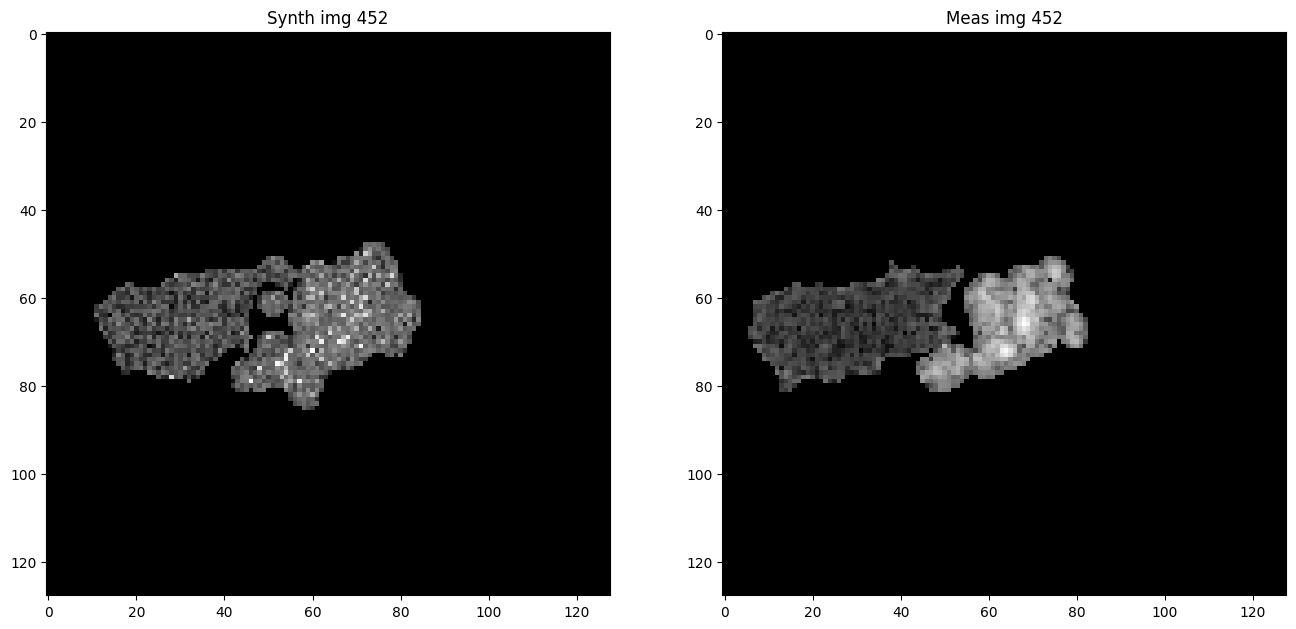

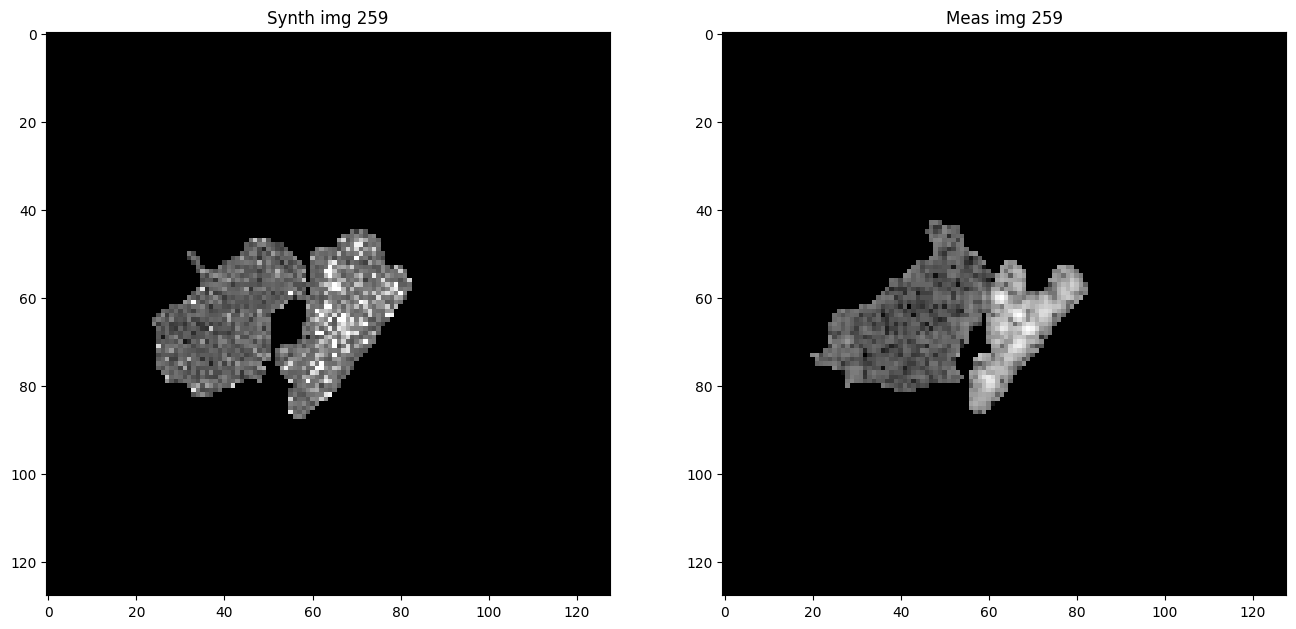

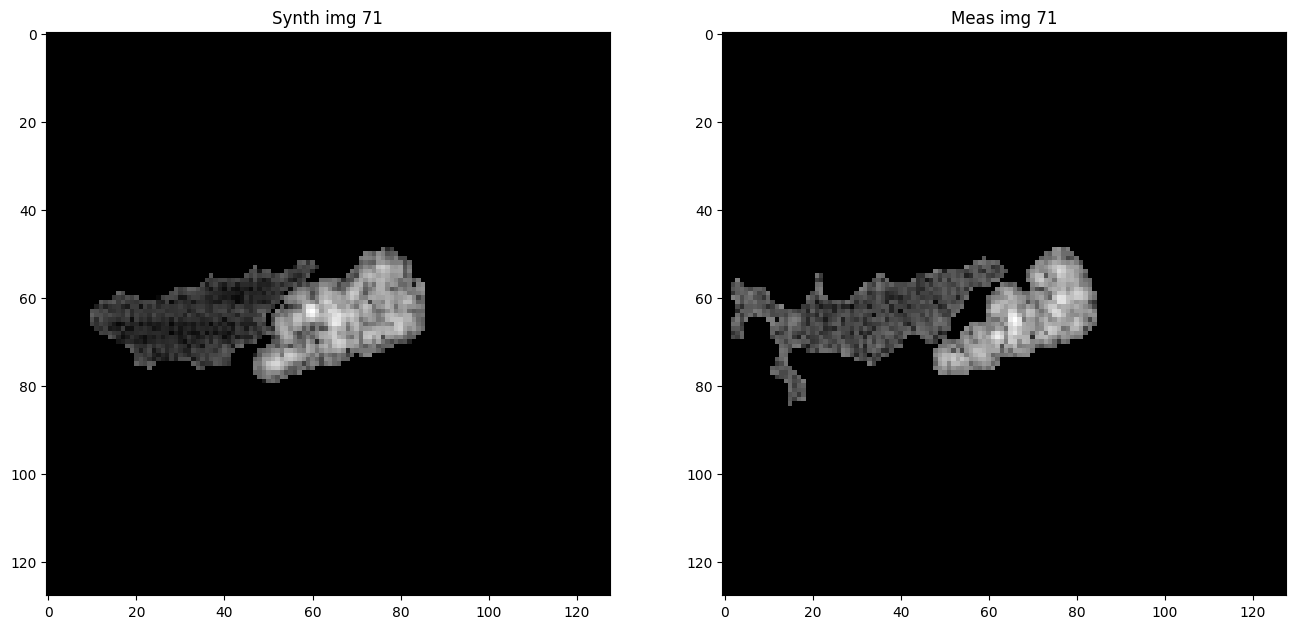

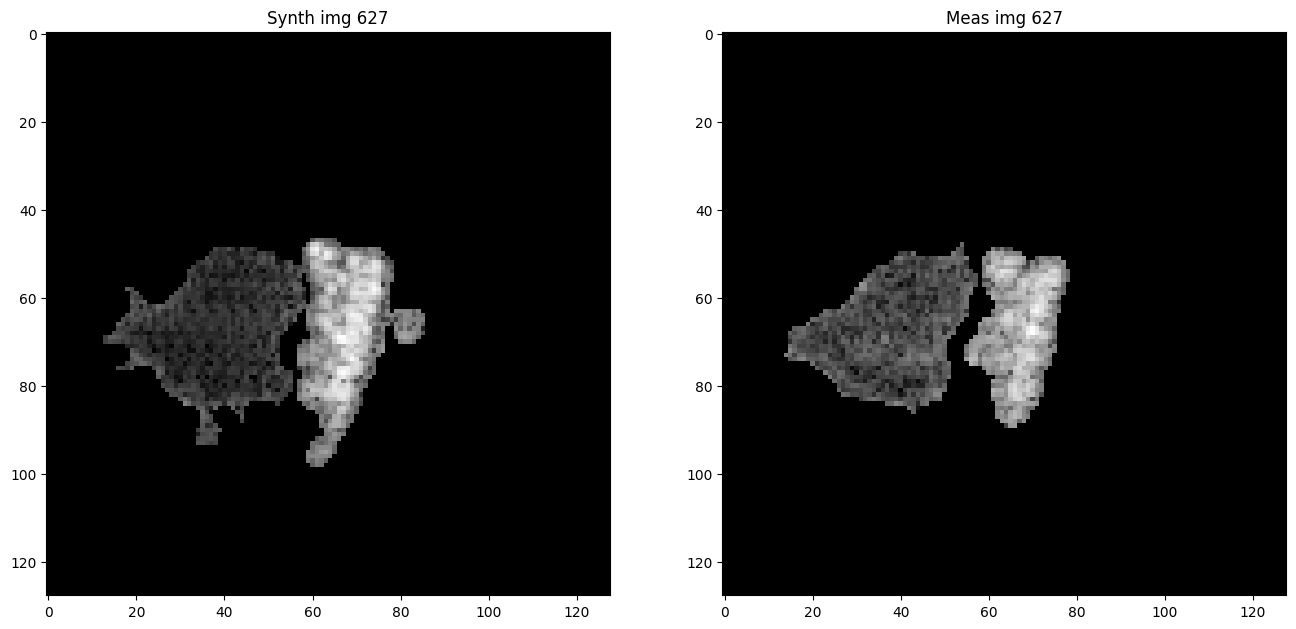

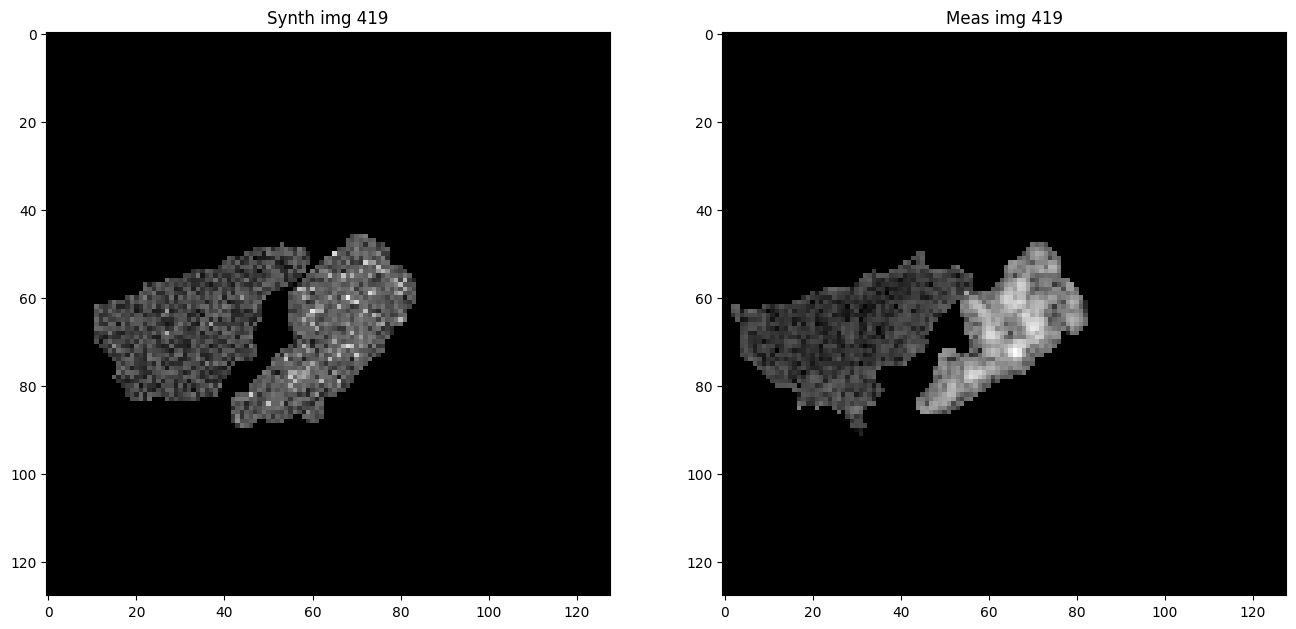

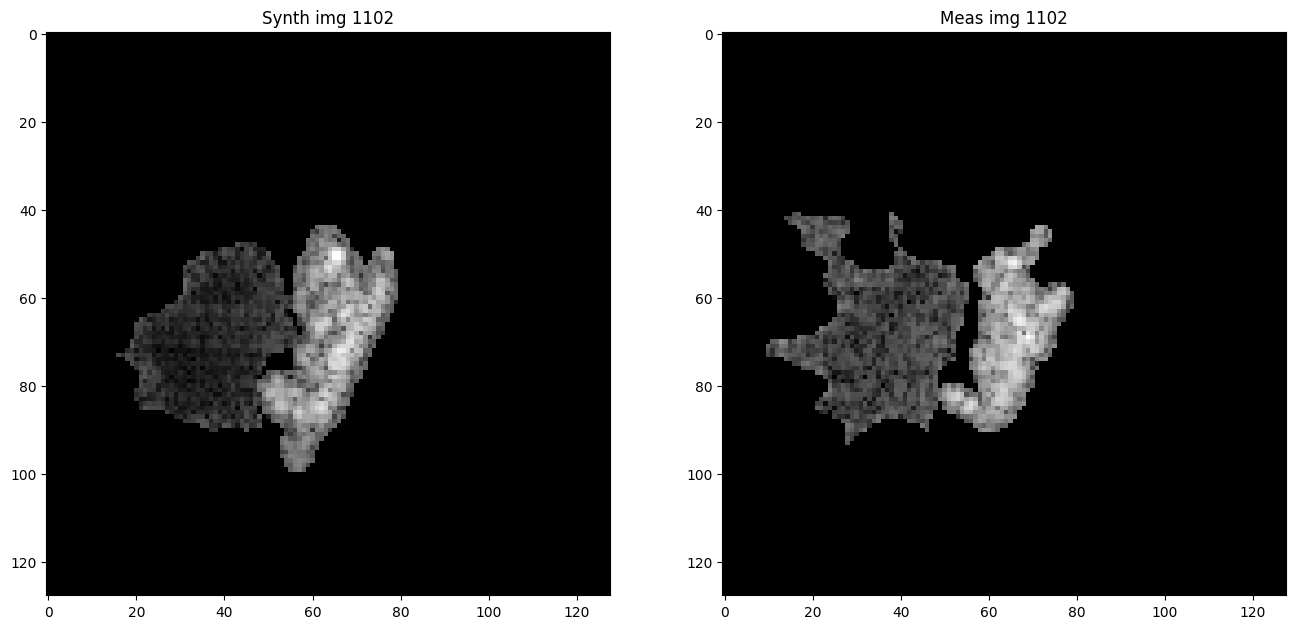

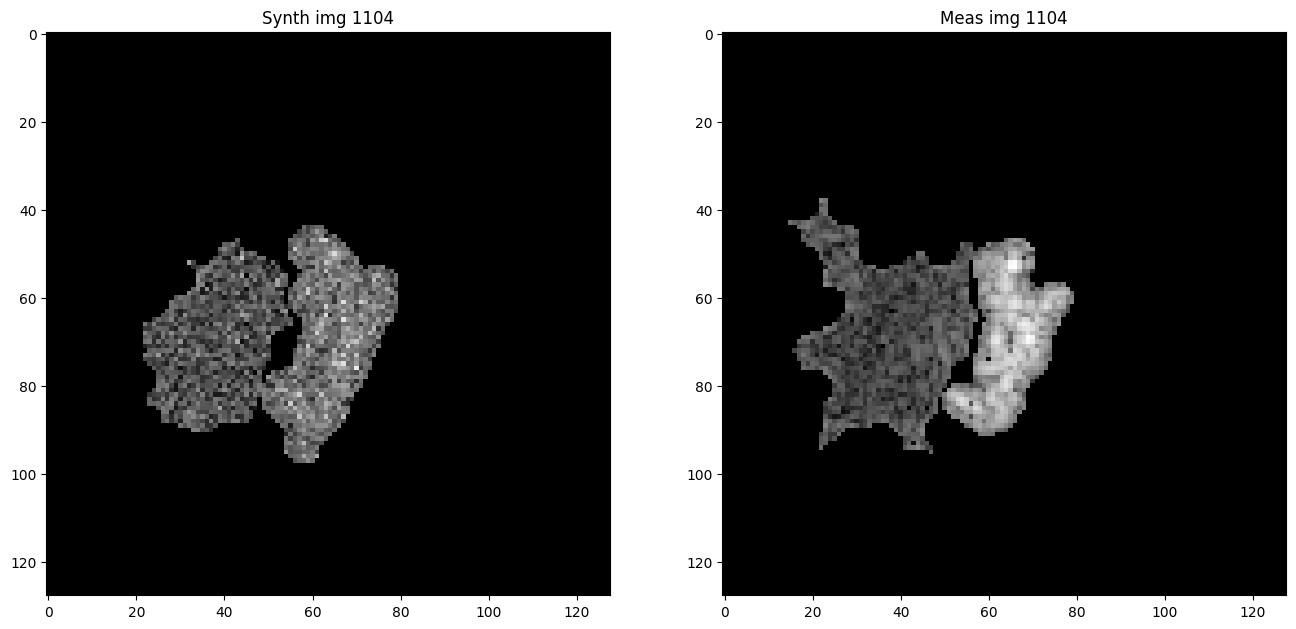

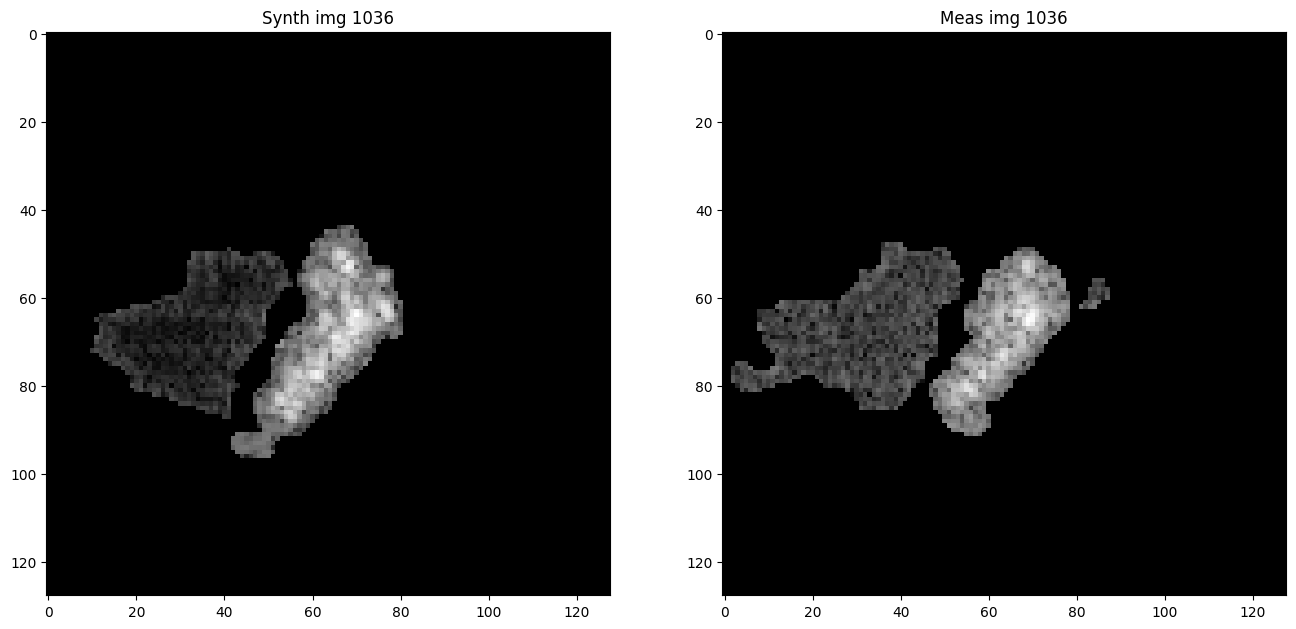

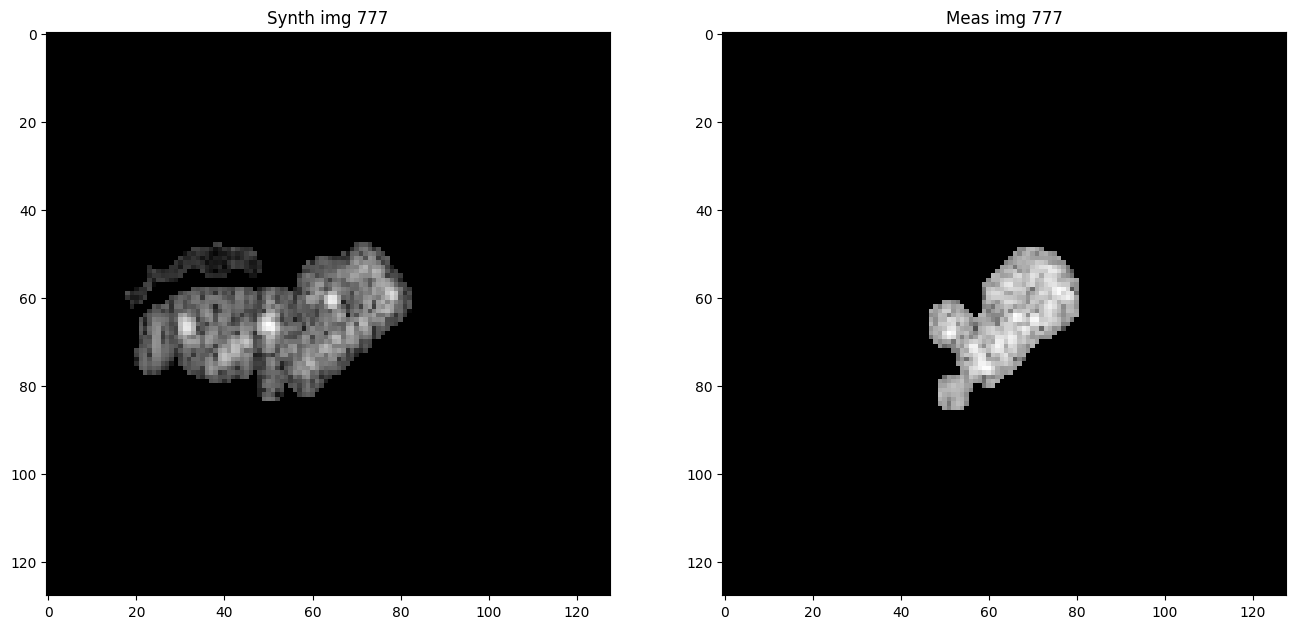

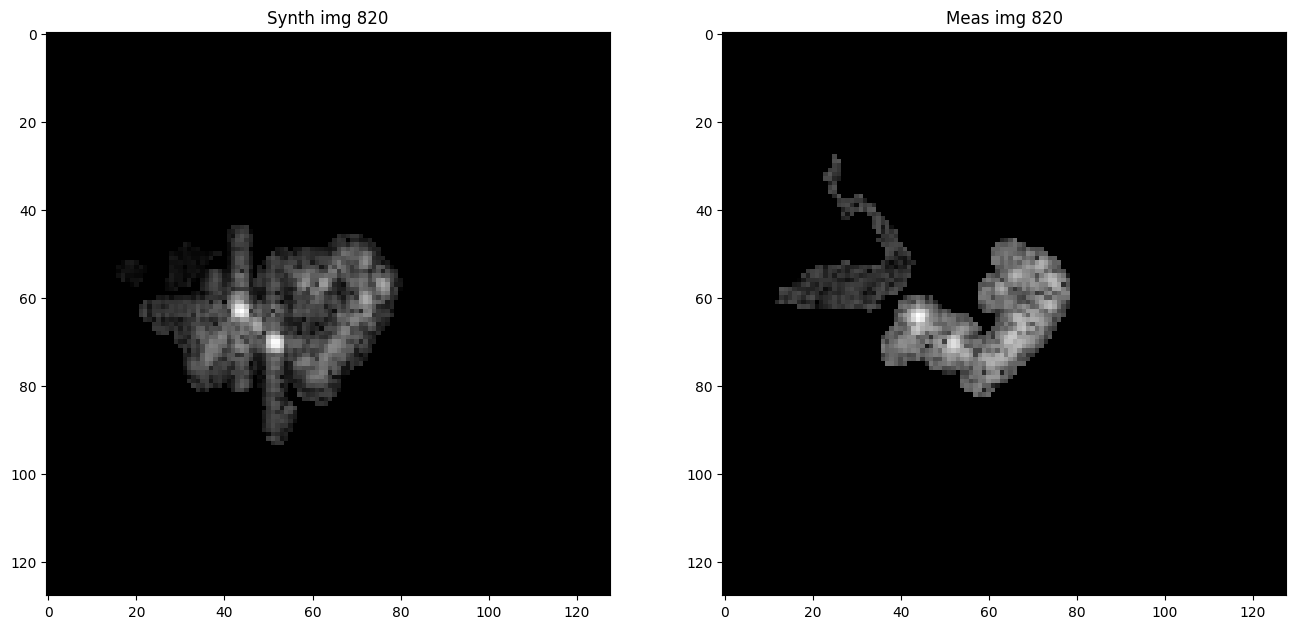

In [10]:
for i in [ 452,  259,   71,  627,  419, 1102, 1104, 1036,  777,  820]:
    synth_img = TS_synth_ds[i][0][0]
    meas_img = TS_meas_ds[i][0][0]

    fig = plt.figure(figsize = (16, 9))
    
    ax0 = fig.add_subplot(1, 2, 1)
    ax0.imshow(synth_img, vmin = 0, vmax = 1, cmap = "gray")
    ax0.set_title(f"Synth img {i}") 
    
    ax1 = fig.add_subplot(1, 2, 2)
    ax1.imshow(meas_img, vmin = 0, vmax = 1, cmap = "gray")
    ax1.set_title(f"Meas img {i}") 

    plt.show()

In [13]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/SSR_w_noise/target_shadow/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(TS_meas_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 0.8513
Evaluating Run 1: Seed 42
Test Accuracy: 0.7993
Evaluating Run 2: Seed 100
Test Accuracy: 0.8424
Evaluating Run 3: Seed 123
Test Accuracy: 0.8082
Evaluating Run 4: Seed 666
Test Accuracy: 0.8119
Evaluating Run 5: Seed 777
Test Accuracy: 0.8126
Evaluating Run 6: Seed 849
Test Accuracy: 0.8112
Evaluating Run 7: Seed 1000
Test Accuracy: 0.7955
Evaluating Run 8: Seed 1111
Test Accuracy: 0.8253
Evaluating Run 9: Seed 1234
Test Accuracy: 0.8431


In [14]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 79.5539
Max: 85.1301
Avg, Std: 82.0074, 1.8465


## Target only

### Fill = 0

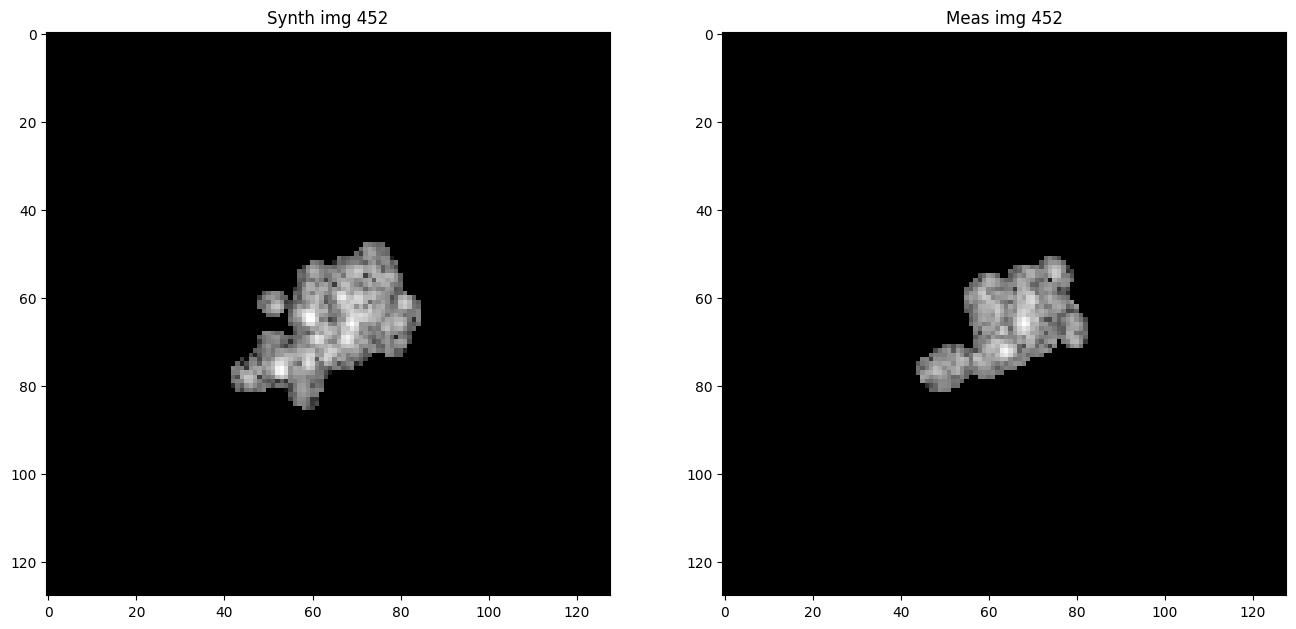

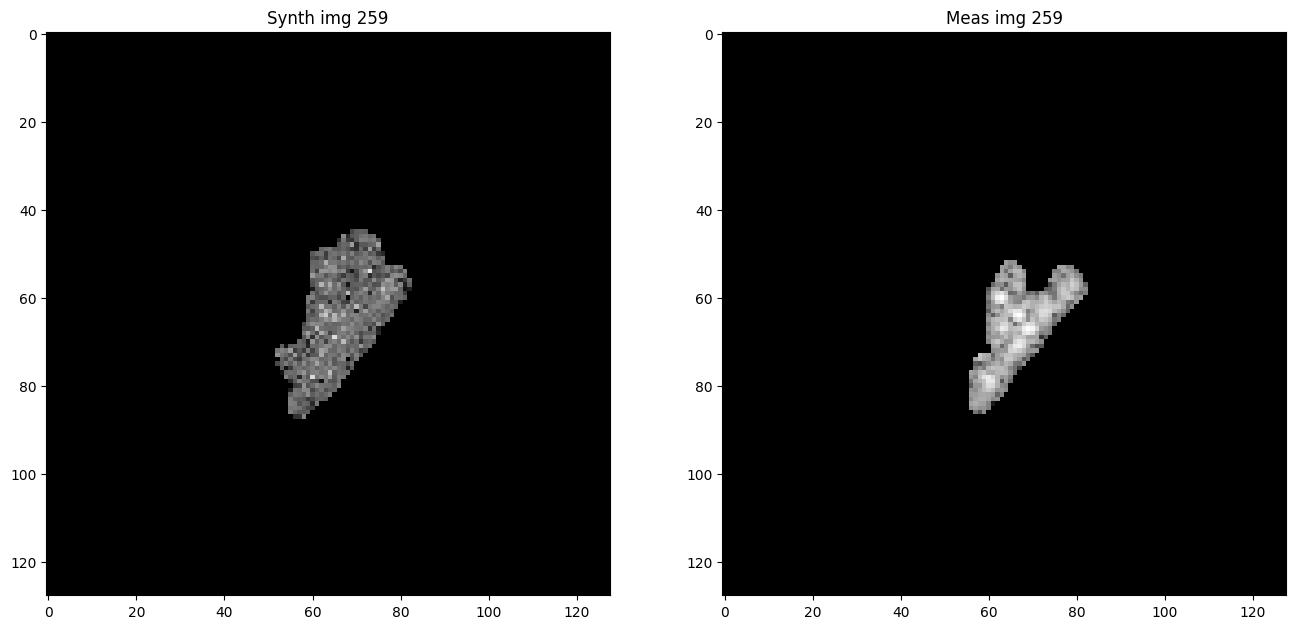

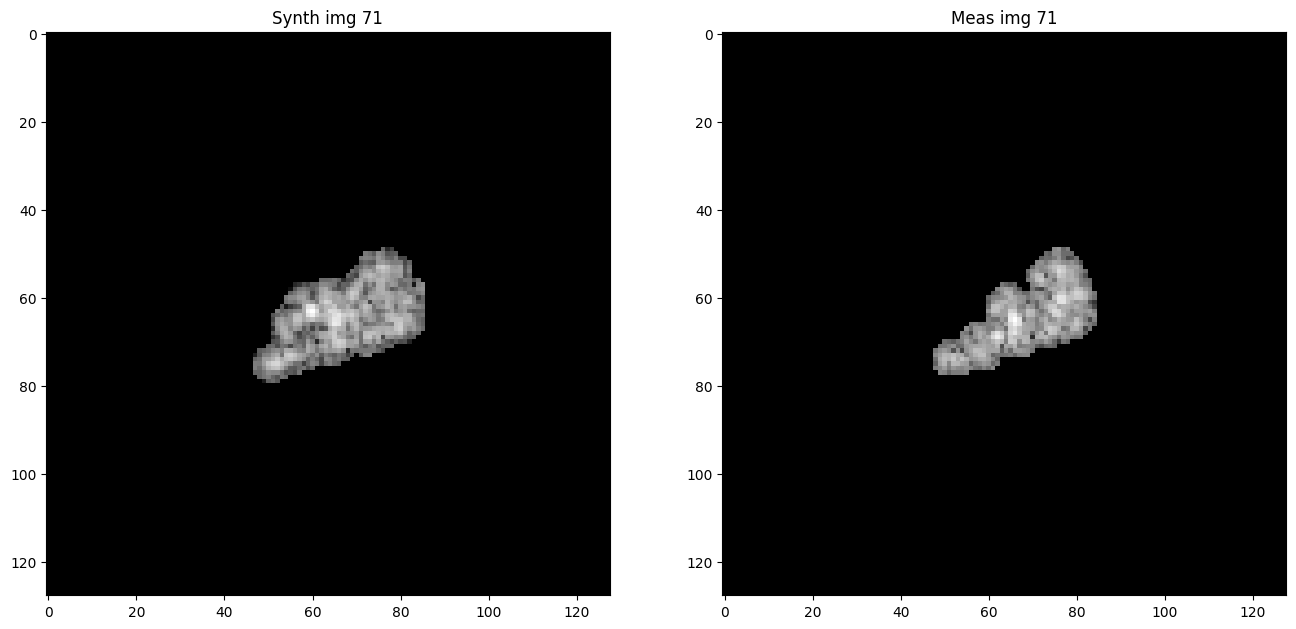

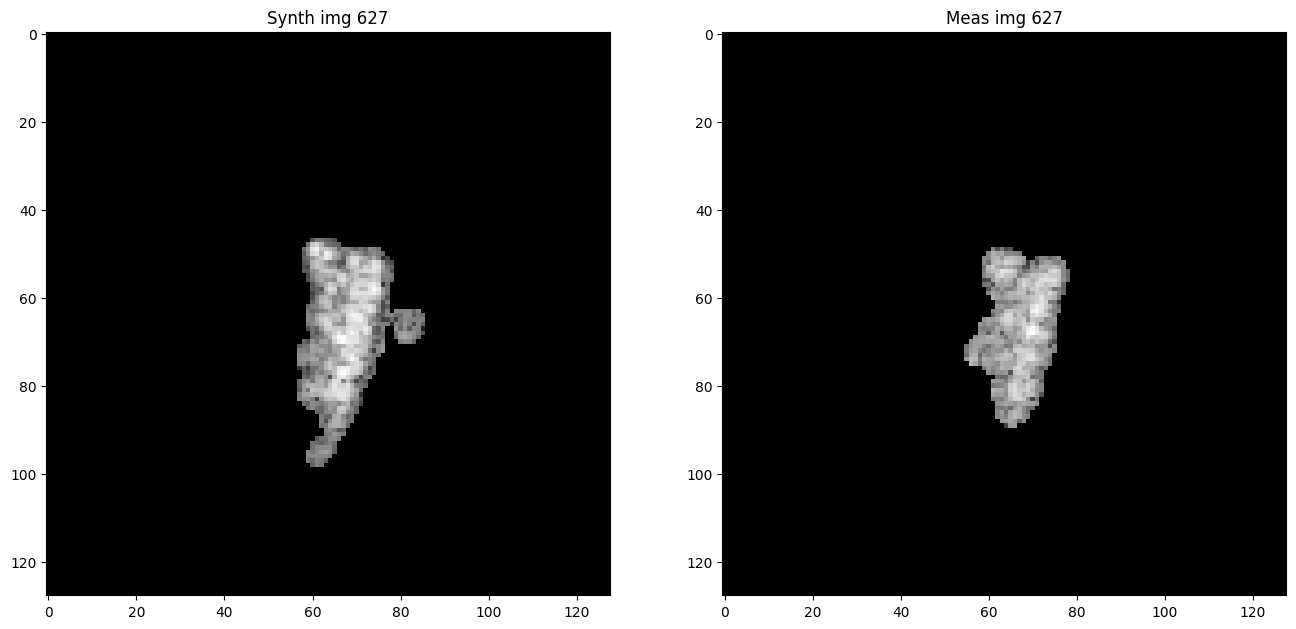

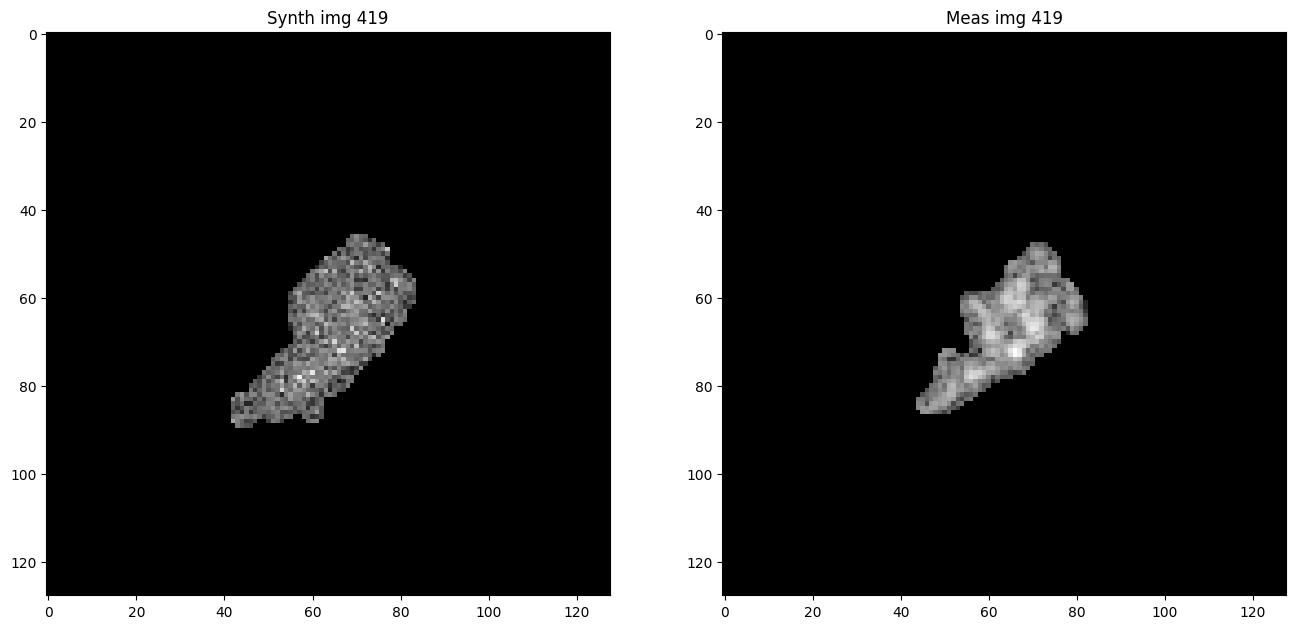

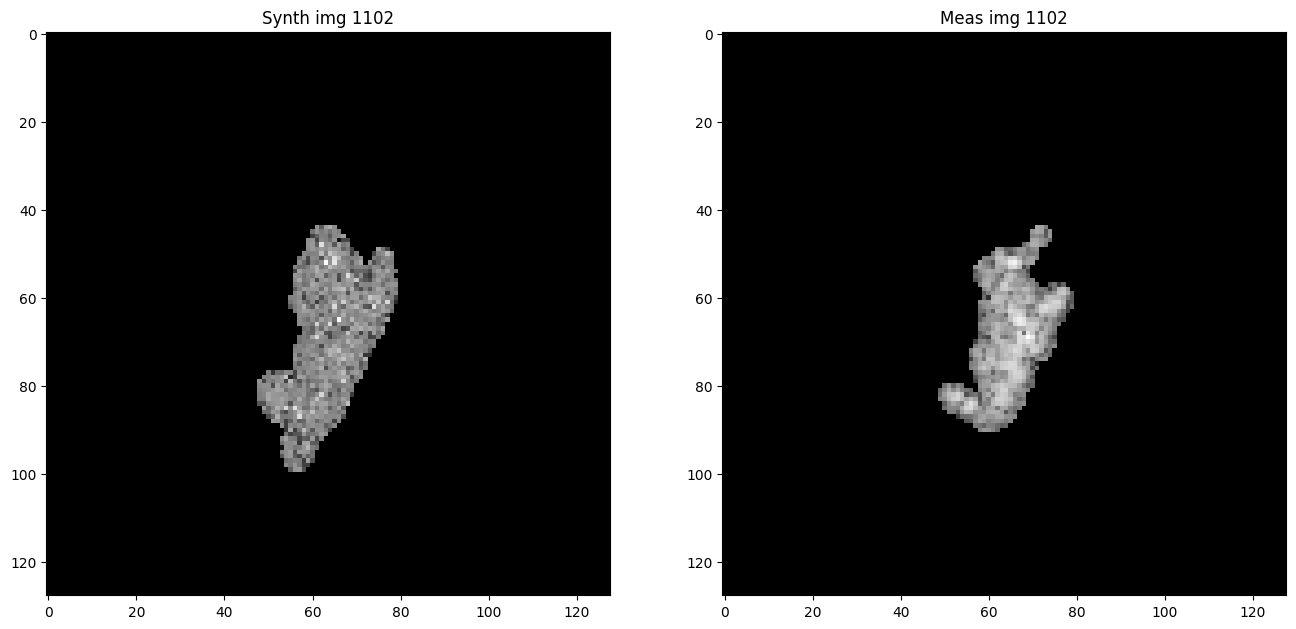

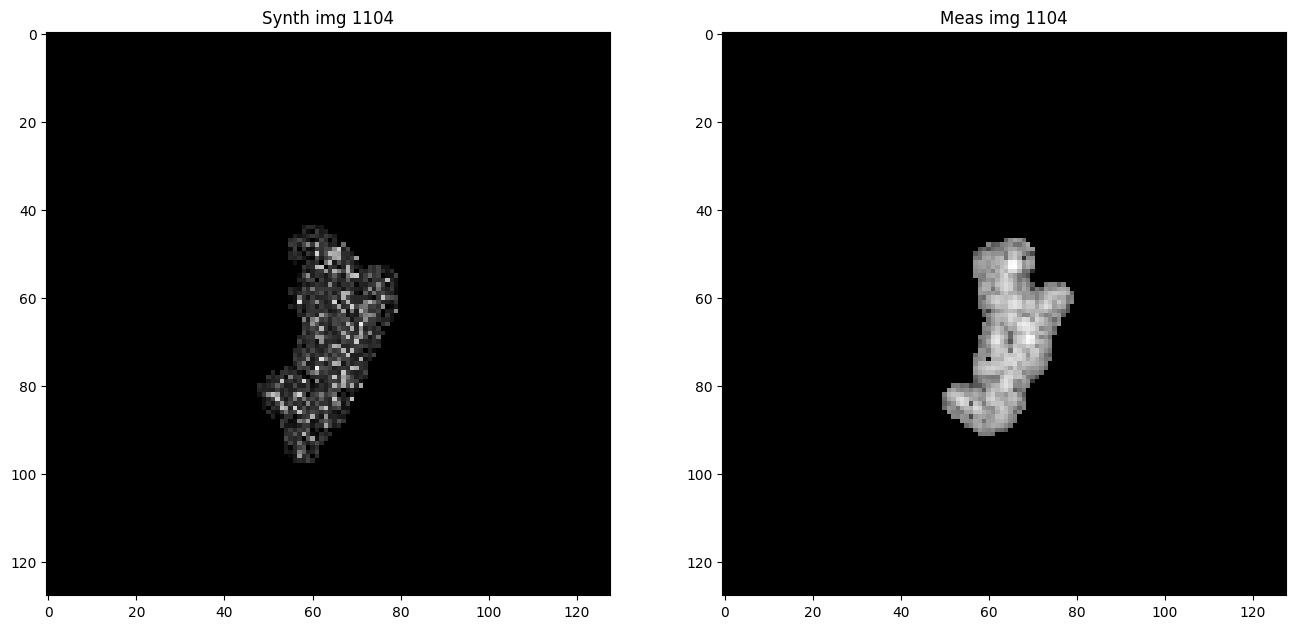

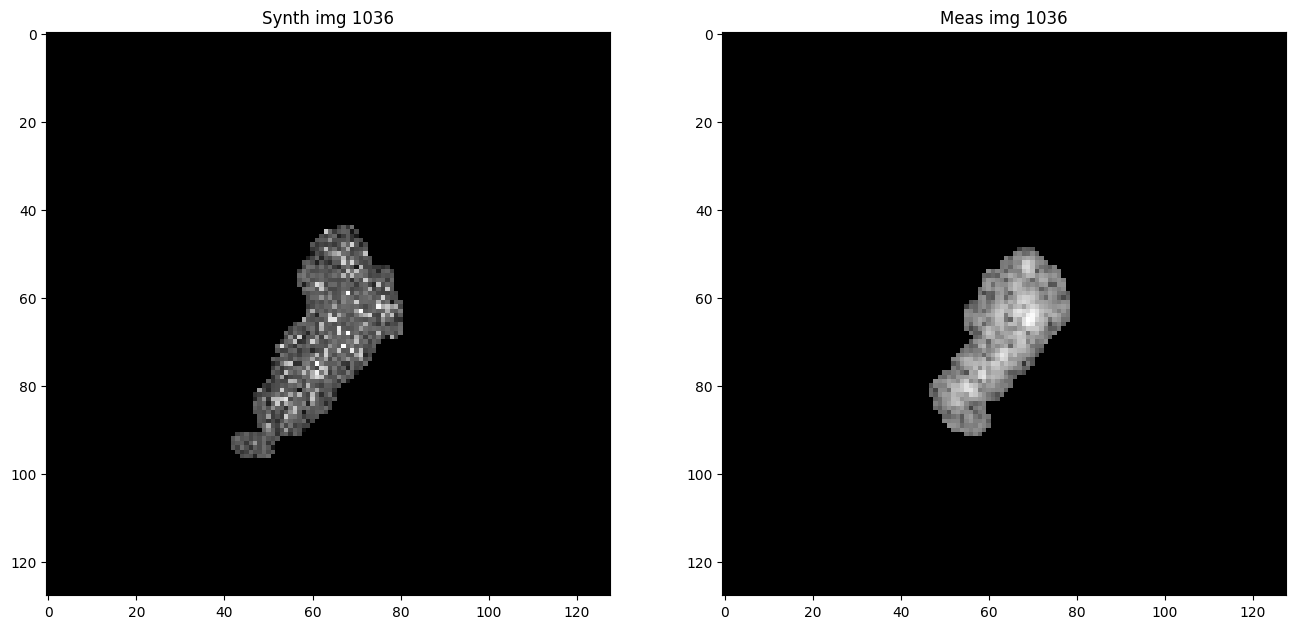

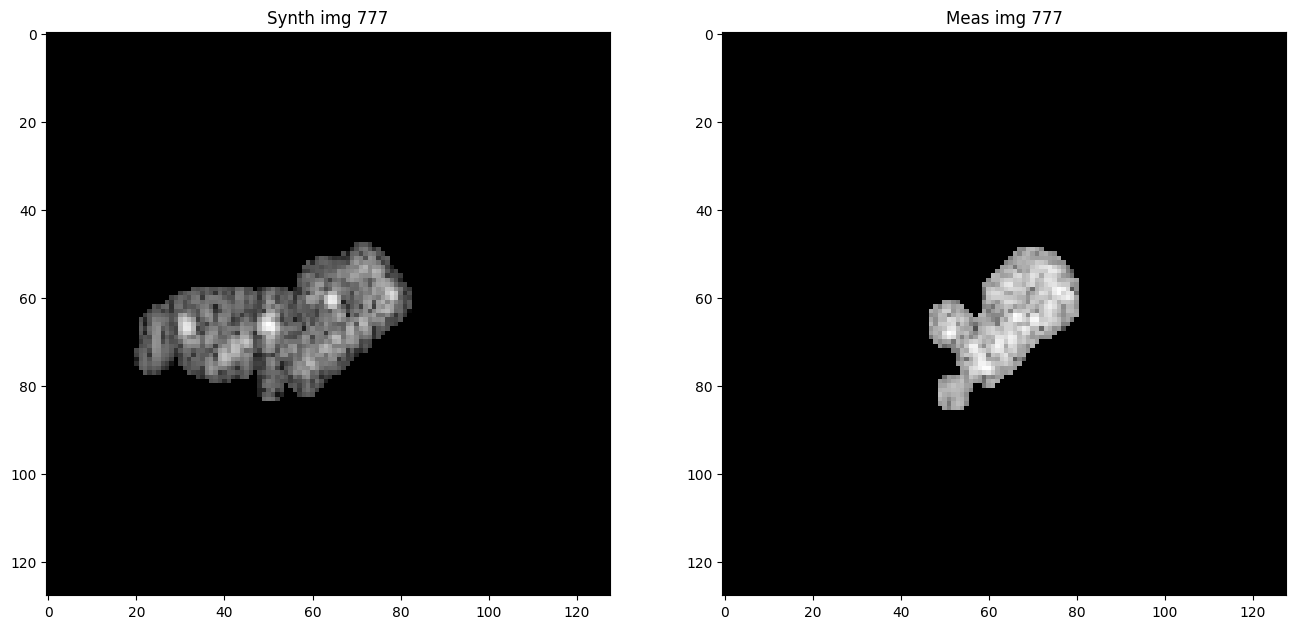

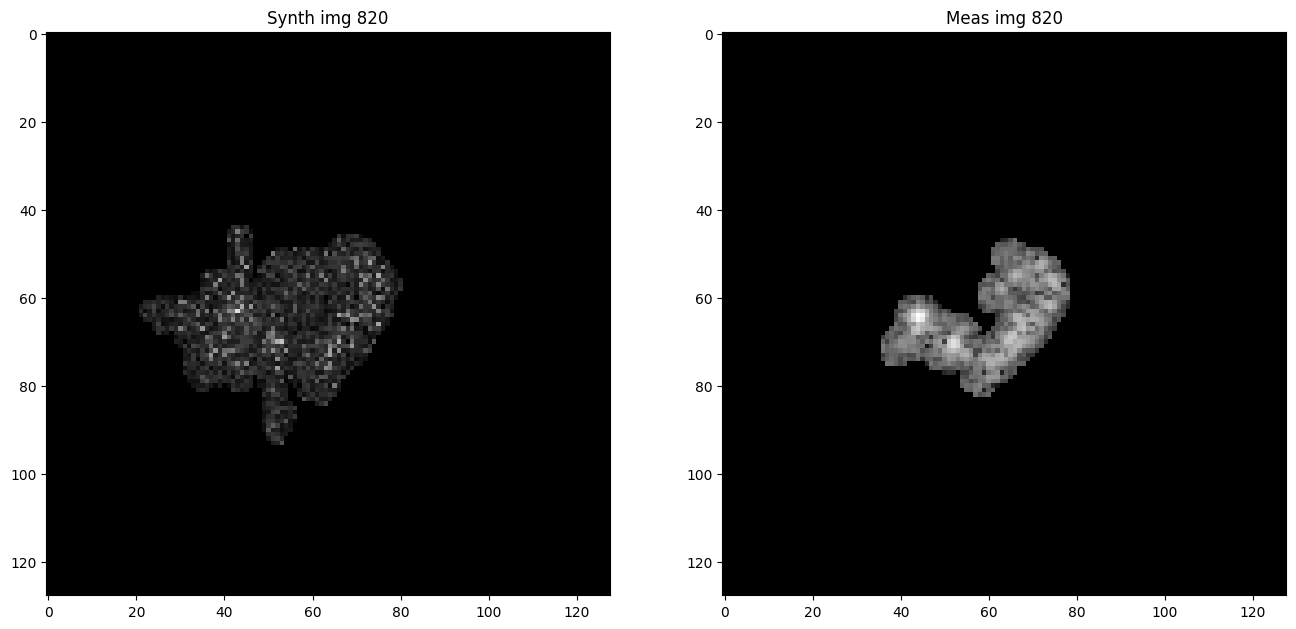

In [10]:
for i in [ 452,  259,   71,  627,  419, 1102, 1104, 1036,  777,  820]:
    synth_img = T_synth_ds[i][0][0]
    meas_img = T_meas_ds[i][0][0]

    fig = plt.figure(figsize = (16, 9))
    
    ax0 = fig.add_subplot(1, 2, 1)
    ax0.imshow(synth_img, vmin = 0, vmax = 1, cmap = "gray")
    ax0.set_title(f"Synth img {i}") 
    
    ax1 = fig.add_subplot(1, 2, 2)
    ax1.imshow(meas_img, vmin = 0, vmax = 1, cmap = "gray")
    ax1.set_title(f"Meas img {i}") 

    plt.show()

In [16]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Segmentation/Zhao_v2/SSR_w_noise/target_only/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(T_meas_ds, batch_size=64, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: Seed 10
Test Accuracy: 0.7643
Evaluating Run 1: Seed 42
Test Accuracy: 0.7182
Evaluating Run 2: Seed 100
Test Accuracy: 0.7294
Evaluating Run 3: Seed 123
Test Accuracy: 0.7494
Evaluating Run 4: Seed 666
Test Accuracy: 0.7331
Evaluating Run 5: Seed 777
Test Accuracy: 0.7472
Evaluating Run 6: Seed 849
Test Accuracy: 0.7071
Evaluating Run 7: Seed 1000
Test Accuracy: 0.7086
Evaluating Run 8: Seed 1111
Test Accuracy: 0.7242
Evaluating Run 9: Seed 1234
Test Accuracy: 0.7487


In [17]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 70.7063
Max: 76.4312
Avg, Std: 73.3011, 1.8110
